In [ ]:
import os
import pandas as pd

table_path = os.path.join(
    "/home/eduardo-da-paz/Documents/master/tablerag-slm/results",
    "final_benchmark.csv"
)

df_bench = pd.read_csv(table_path)



In [51]:
# ordem desejada das colunas
ordem_metodos = [
    "zero-shot",
    "content-aware",
    # "embedding-retrieval",
    "embedding-content-aware",
    "schema-linking"
]

# ordem desejada dos modelos
ordem_modelos = [
    "llama3.2:3b",
    "deepseek-coder:6.7b",
    "qwen2.5-coder:7b",
    "gemma4:e4b",
    "gpt-oss-120b",
    "llama-3.3-70b"
]


tabela_acuracia = df_bench.pivot_table(
    index='model_name',
    columns='prompt_method',
    values='correct',
    aggfunc='mean'
)

tabela_acuracia_pct = tabela_acuracia * 100

# reordena colunas e linhas
tabela_acuracia_pct = tabela_acuracia_pct[ordem_metodos]
tabela_acuracia_pct = tabela_acuracia_pct.reindex(ordem_modelos)

print("=== ACURÁCIA DE DENOTAÇÃO (%) POR MODELO E PROMPT ===")
display(tabela_acuracia_pct.round(2))

# print(tabela_acuracia_pct.round(2).to_latex())

=== ACURÁCIA DE DENOTAÇÃO (%) POR MODELO E PROMPT ===


prompt_method,zero-shot,content-aware,embedding-content-aware,schema-linking
model_name,,,,
llama3.2:3b,14.4,24.0,28.0,24.3
deepseek-coder:6.7b,21.7,29.1,32.6,28.4
qwen2.5-coder:7b,25.3,37.8,42.0,36.4
gemma4:e4b,19.8,38.9,47.9,42.2
gpt-oss-120b,24.0,34.4,38.4,33.1
llama-3.3-70b,22.4,31.8,47.1,41.9


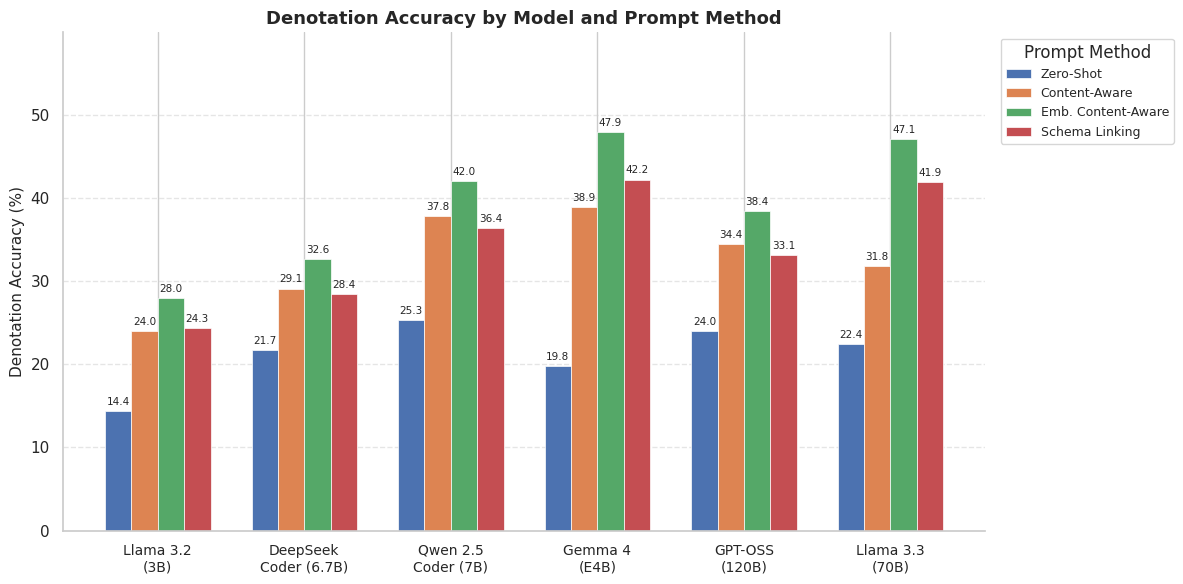

In [52]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Labels mais limpos para exibição
label_modelos = {
    "llama3.2:3b": "Llama 3.2\n(3B)",
    "deepseek-coder:6.7b": "DeepSeek\nCoder (6.7B)",
    "qwen2.5-coder:7b": "Qwen 2.5\nCoder (7B)",
    "gemma4:e4b": "Gemma 4\n(E4B)",
    "gpt-oss-120b": "GPT-OSS\n(120B)",
    "llama-3.3-70b": "Llama 3.3\n(70B)",
}

label_metodos = {
    "zero-shot": "Zero-Shot",
    "content-aware": "Content-Aware",
    "embedding-content-aware": "Emb. Content-Aware",
    "schema-linking": "Schema Linking",
}

cores = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

df_plot = tabela_acuracia_pct.rename(index=label_modelos, columns=label_metodos)

modelos = df_plot.index.tolist()
metodos = df_plot.columns.tolist()
x = np.arange(len(modelos))
n = len(metodos)
width = 0.18
offsets = np.linspace(-(n - 1) / 2, (n - 1) / 2, n) * width

fig, ax = plt.subplots(figsize=(12, 6))

for i, (metodo, cor) in enumerate(zip(metodos, cores)):
    valores = df_plot[metodo].values
    bars = ax.bar(x + offsets[i], valores, width=width, label=metodo,
                  color=cor, edgecolor="white", linewidth=0.5)
    # valor em cima de cada barra
    for bar, v in zip(bars, valores):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f"{v:.1f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=10)
ax.set_ylabel("Denotation Accuracy (%)", fontsize=11)
ax.set_title("Denotation Accuracy by Model and Prompt Method", fontsize=13, fontweight="bold")
ax.set_ylim(0, tabela_acuracia_pct.max().max() + 12)
ax.legend(title="Prompt Method", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("accuracy_by_model_method.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [ ]:
# Agrupa por modelo e prompt para ver a taxa de sucesso de execução
robustez_sintatica = df_bench.groupby(['model_name', 'prompt_method']).agg(
    total_samples=('correct', 'count'),
    sql_gerado_pct=('sql_generated', 'mean'),
    execucao_sucesso_pct=('execution_success', 'mean'),
    acerto_final_pct=('correct', 'mean')
)

# Transforma em porcentagem para facilitar a leitura
for col in ['sql_gerado_pct', 'execucao_sucesso_pct', 'acerto_final_pct']:
    robustez_sintatica[col] = robustez_sintatica[col] * 100

print("=== ANÁLISE DE ROBUSTEZ SINTÁTICA ===")
display(robustez_sintatica.round(2))
print(robustez_sintatica.round(2).to_latex())

=== ANÁLISE DE ROBUSTEZ SINTÁTICA ===


total_samples  sql_gerado_pct  \
model_name          prompt_method                                            
deepseek-coder:6.7b content-aware                     1000           100.0   
                    embedding-content-aware           1000           100.0   
                    embedding-retrieval               1000           100.0   
                    schema-linking                    1000           100.0   
                    zero-shot                         1000           100.0   
gemma4:e4b          content-aware                     1000           100.0   
                    embedding-content-aware           1000           100.0   
                    embedding-retrieval               1000           100.0   
                    schema-linking                    1000           100.0   
                    zero-shot                         1000           100.0   
gpt-oss-120b        content-aware                     1000            61.1   
                    embedding-content-aware           1000            63.9   
                    embedding-retrieval               1000            64.7   
                    schema-linking                    1000            59.7   
                    zero-shot                         1000            73.2   
llama-3.3-70b       content-aware                     1000           100.0   
                    embedding-content-aware           1000           100.0   
                    embedding-retrieval               1000           100.0   
                    schema-linking                    1000           100.0   
                    zero-shot                         1000           100.0   
llama3.2:3b         content-aware                     1000           100.0   
                    embedding-content-aware           1000           100.0   
                    embedding-retrieval               1000           100.0   
                    schema-linking                    1000           100.0   
                    zero-shot                         1000           100.0   
qwen2.5-coder:7b    content-aware                     1000           100.0   
                    embedding-content-aware           1000           100.0   
                    embedding-retrieval               1000           100.0   
                    schema-linking                    1000           100.0   
                    zero-shot                         1000           100.0   

                                             execucao_sucesso_pct  \
model_name          prompt_method                                   
deepseek-coder:6.7b content-aware                            96.7   
                    embedding-content-aware                  97.0   
                    embedding-retrieval                      86.7   
                    schema-linking                           95.1   
                    zero-shot                                95.8   
gemma4:e4b          content-aware                            96.8   
                    embedding-content-aware                  96.9   
                    embedding-retrieval                      95.4   
                    schema-linking                           92.3   
                    zero-shot                                95.8   
gpt-oss-120b        content-aware                            53.9   
                    embedding-content-aware                  58.4   
                    embedding-retrieval                      57.5   
                    schema-linking                           54.0   
                    zero-shot                                66.6   
llama-3.3-70b       content-aware                            81.1   
                    embedding-content-aware                  94.0   
                    embedding-retrieval                      89.3   
                    schema-linking                           93.1   
                    zero-shot                                72.8   
llama3.2:3b         content-aw

\begin{tabular}{llrrrr}
\toprule
 &  & total_samples & sql_gerado_pct & execucao_sucesso_pct & acerto_final_pct \\
model_name & prompt_method &  &  &  &  \\
\midrule
\multirow[t]{5}{*}{deepseek-coder:6.7b} & content-aware & 1000 & 100.000000 & 96.700000 & 29.100000 \\
 & embedding-content-aware & 1000 & 100.000000 & 97.000000 & 32.600000 \\
 & embedding-retrieval & 1000 & 100.000000 & 86.700000 & 31.200000 \\
 & schema-linking & 1000 & 100.000000 & 95.100000 & 28.400000 \\
 & zero-shot & 1000 & 100.000000 & 95.800000 & 21.700000 \\
\cline{1-6}
\multirow[t]{5}{*}{gemma4:e4b} & content-aware & 1000 & 100.000000 & 96.800000 & 38.900000 \\
 & embedding-content-aware & 1000 & 100.000000 & 96.900000 & 47.900000 \\
 & embedding-retrieval & 1000 & 100.000000 & 95.400000 & 45.900000 \\
 & schema-linking & 1000 & 100.000000 & 92.300000 & 42.200000 \\
 & zero-shot & 1000 & 100.000000 & 95.800000 & 19.800000 \\
\cline{1-6}
\multirow[t]{5}{*}{gpt-oss-120b} & content-aware & 1000 & 61.100000 & 53.90

In [28]:
# Média de latência e tokens por estratégia de prompt (sem retrieved_rows)
eficiencia_prompt = df_bench.groupby('prompt_method').agg(
    latencia_media_seg=('latency_seconds', 'mean'),
    tokens_medios_prompt=('prompt_tokens', 'mean')
).sort_values(by='latencia_media_seg')

print("=== IMPACTO DO MÉTODO DE PROMPT NA EFICIÊNCIA ===")
display(eficiencia_prompt.round(2))

print("\n" + "="*50 + "\n")

# Média de latência por modelo
eficiencia_modelo = df_bench.groupby('model_name').agg(
    latencia_media_seg=('latency_seconds', 'mean'),
    tokens_medios_prompt=('prompt_tokens', 'mean')
).sort_values(by='latencia_media_seg')

print("=== CUSTO COMPUTACIONAL POR MODELO ===")
display(eficiencia_modelo.round(2))
print(eficiencia_modelo.round(2).to_latex())

=== IMPACTO DO MÉTODO DE PROMPT NA EFICIÊNCIA ===


,latencia_media_seg,tokens_medios_prompt
prompt_method,,
zero-shot,1.43,85.46
content-aware,1.89,167.94
embedding-retrieval,2.17,117.78
embedding-content-aware,2.21,149.78
schema-linking,2.37,147.22




=== CUSTO COMPUTACIONAL POR MODELO ===


,latencia_media_seg,tokens_medios_prompt
model_name,,
llama3.2:3b,0.33,133.64
deepseek-coder:6.7b,0.69,133.64
qwen2.5-coder:7b,0.71,133.64
llama-3.3-70b,0.84,133.64
gpt-oss-120b,2.14,133.64
gemma4:e4b,7.37,133.64


\begin{tabular}{lrr}
\toprule
 & latencia_media_seg & tokens_medios_prompt \\
model_name &  &  \\
\midrule
llama3.2:3b & 0.330000 & 133.640000 \\
deepseek-coder:6.7b & 0.690000 & 133.640000 \\
qwen2.5-coder:7b & 0.710000 & 133.640000 \\
llama-3.3-70b & 0.840000 & 133.640000 \\
gpt-oss-120b & 2.140000 & 133.640000 \\
gemma4:e4b & 7.370000 & 133.640000 \\
\bottomrule
\end{tabular}



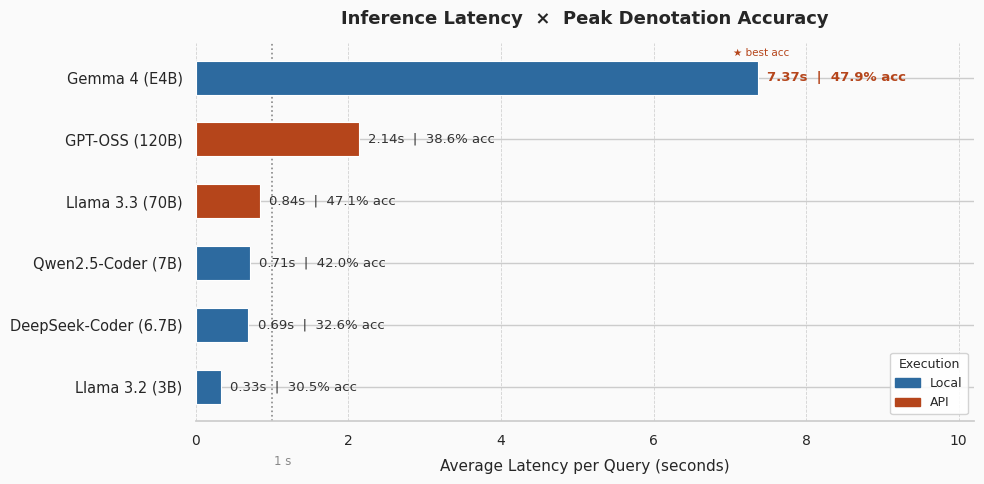

In [53]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np

# ── Dados ──────────────────────────────────────────────────────────────────
dados_grafico = {
    'Model':    ['Llama 3.2 (3B)', 'DeepSeek-Coder (6.7B)', 'Qwen2.5-Coder (7B)',
                 'Llama 3.3 (70B)', 'GPT-OSS (120B)', 'Gemma 4 (E4B)'],
    'Latency':  [0.33, 0.69, 0.71, 0.84, 2.14, 7.37],
    'Accuracy': [30.50, 32.60, 42.00, 47.10, 38.60, 47.90],
    'Type':     ['Local', 'Local', 'Local', 'API', 'API', 'Local']
}
df = pd.DataFrame(dados_grafico).sort_values('Latency', ascending=True)

# ── Paleta: local vs API ────────────────────────────────────────────────────
color_map  = {'Local': '#2D6A9F', 'API': '#B5451B'}
bar_colors = [color_map[t] for t in df['Type']]

# ── Figura ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

# ── Barras ──────────────────────────────────────────────────────────────────
bars = ax.barh(df['Model'], df['Latency'],
               color=bar_colors, height=0.55,
               edgecolor='white', linewidth=0.8,
               zorder=3)

# ── Grade só no eixo X ──────────────────────────────────────────────────────
ax.xaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.5, color='#AAAAAA', zorder=0)
ax.set_axisbelow(True)

# ── Destaque do melhor accuracy ─────────────────────────────────────────────
best_acc_idx = df['Accuracy'].idxmax()
best_model   = df.loc[best_acc_idx, 'Model']

for bar, (_, row) in zip(bars, df.iterrows()):
    w = bar.get_width()
    is_best = row['Model'] == best_model

    # Anotação de latência + acurácia
    label = f"{w:.2f}s  |  {row['Accuracy']:.1f}% acc"
    weight = 'bold' if is_best else 'normal'
    color  = '#B5451B' if is_best else '#333333'

    ax.text(w + 0.12, bar.get_y() + bar.get_height() / 2,
            label, va='center', ha='left',
            fontsize=9.5, fontweight=weight, color=color)

    # Estrela no melhor modelo
    if is_best:
        ax.text(w + 0.12 - 0.45, bar.get_y() + bar.get_height() / 2 + 0.32,
                '★ best acc', fontsize=7.5, color='#B5451B', va='bottom')

# ── Linha vertical de referência (1 segundo) ────────────────────────────────
ax.axvline(1.0, color='#888888', linestyle=':', linewidth=1.2, zorder=2)
ax.text(1.02, ax.get_ylim()[0] - 0.55, '1 s', fontsize=8.5,
        color='#888888', ha='left', va='top')

# ── Rótulos e título ─────────────────────────────────────────────────────────
ax.set_xlabel('Average Latency per Query (seconds)', fontsize=11, labelpad=8)
ax.set_title('Inference Latency  ×  Peak Denotation Accuracy',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlim(0, 10.2)
ax.tick_params(axis='y', labelsize=10.5)
ax.tick_params(axis='x', labelsize=10)

# ── Legenda Local vs API ─────────────────────────────────────────────────────
patches = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
ax.legend(handles=patches, title='Execution', title_fontsize=9,
          fontsize=9, loc='lower right', framealpha=0.85,
          edgecolor='#CCCCCC')

# ── Bordas ───────────────────────────────────────────────────────────────────
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig('latency_vs_accuracy.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [34]:
df_bench.groupby(['model_name', 'prompt_method'])['latency_seconds'].mean()

model_name           prompt_method          
deepseek-coder:6.7b  content-aware              0.608061
                     embedding-content-aware    0.679451
                     embedding-retrieval        0.919674
                     schema-linking             0.668196
                     zero-shot                  0.559111
gemma4:e4b           content-aware              6.979777
                     embedding-content-aware    8.425492
                     embedding-retrieval        7.862345
                     schema-linking             9.178785
                     zero-shot                  4.407949
gpt-oss-120b         content-aware              1.971291
                     embedding-content-aware    2.163379
                     embedding-retrieval        2.396930
                     schema-linking             2.463990
                     zero-shot                  1.697298
llama-3.3-70b        content-aware              0.752477
                     embedding-content-awar

In [35]:
# Mostra média, desvio padrão (std), mínimo, máximo e os percentis da latência por modelo
df_bench.groupby('model_name')['latency_seconds'].describe(percentiles=[0.5, 0.9, 0.95])

,count,mean,std,min,50%,90%,95%,max
model_name,,,,,,,,
deepseek-coder:6.7b,5000.0,0.686898,0.528570,0.256663,0.560066,1.023224,1.343854,9.536919
gemma4:e4b,5000.0,7.370869,7.155651,0.349828,5.284063,16.490484,21.066652,78.115561
gpt-oss-120b,5000.0,2.138578,1.426341,0.529182,1.842413,3.489577,4.374832,52.348720
llama-3.3-70b,5000.0,0.839979,0.784937,0.324522,0.637734,1.376326,1.883873,19.948029
llama3.2:3b,5000.0,0.327694,0.116498,0.155401,0.303284,0.447990,0.524733,2.868376
qwen2.5-coder:7b,5000.0,0.712941,0.295773,0.289636,0.640793,1.027615,1.194736,6.660815


In [ ]:
# Filtra apenas onde houve falha de execução
df_falhas = df_bench[df_bench['execution_success'] == False]

print("=== DISTRIBUIÇÃO GERAL DOS ERROS DE EXECUÇÃO ===")
print(df_falhas['execution_error'].value_counts().head(10))
print("\n" + "="*50 + "\n")

# Detalha os top 3 erros mais comuns por par (Modelo, Prompt)
def top_erros(group):
    return group['execution_error'].value_counts().head(3)

erros_por_config = df_falhas.groupby([print("=== DISTRIBUIÇÃO GERAL ===")
print(df_falhas['execution_error'].value_counts().head(10).to_string())

print("\n=== POR MODELO ===")
print(df_falhas.groupby('model_name')['execution_error'].value_counts().head(20).to_string())

print("\n=== EXEMPLO DE ERROS COMPLETOS (5 amostras) ===")
for err in df_falhas['execution_error'].dropna().unique()[:5]:
    print(f"\n--- {err[:80]} ---")
    sample = df_falhas[df_falhas['execution_error'] == err].iloc[0]
    print(f"Model: {sample['model_name']} | Method: {sample['prompt_method']}")'model_name', 'prompt_method']).apply(top_erros)

print("=== TOP ERROS ESPECÍFICOS POR MODELO E PROMPT ===")
display(erros_por_config)

=== DISTRIBUIÇÃO GERAL DOS ERROS DE EXECUÇÃO ===
execution_error
'NoneType' object is not iterable                                                                                                                                     1774
Execution failed on sql 'SELECT': incomplete input                                                                                                                      13
Execution failed on sql 'SELECT ethnicity FROM table_204_257 ORDER BY one_thousand,_nine_hundred_and_twenty_six_census DESC LIMIT 1': no such column: one_thousand       9
Execution failed on sql 'SELECT MIN females FROM table_203_88': no such column: MIN                                                                                      6
Execution failed on sql 'SELECT MIN length FROM table_203_38': no such column: MIN                                                                                       6
Execution failed on sql 'SELECT MAX penalties_p_plus_p_plus_s_plus_s FROM table_

model_name           prompt_method            execution_error                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
deepseek-coder:6.7b  content-aware            Execution failed on sql 'SELECT (r1.runners_up - r2.runners_up) as runner_ups_difference \nFROM table_203_362 t1, table_203_362 t2 \nWHERE t1.school = 'Coleraine Academical Institution' AND t2.school = 'Royal School Dungannon';': no such column: r1.runners_up                                                                                                                   

In [55]:
print("=== DISTRIBUIÇÃO GERAL ===")
print(df_falhas['execution_error'].value_counts().head(10).to_string())

print("\n=== POR MODELO ===")
print(df_falhas.groupby('model_name')['execution_error'].value_counts().head(20).to_string())

print("\n=== EXEMPLO DE ERROS COMPLETOS (5 amostras) ===")
for err in df_falhas['execution_error'].dropna().unique()[:5]:
    print(f"\n--- {err[:80]} ---")
    sample = df_falhas[df_falhas['execution_error'] == err].iloc[0]
    print(f"Model: {sample['model_name']} | Method: {sample['prompt_method']}")

=== DISTRIBUIÇÃO GERAL ===
execution_error
'NoneType' object is not iterable                                                                                                                                     1774
Execution failed on sql 'SELECT': incomplete input                                                                                                                      13
Execution failed on sql 'SELECT ethnicity FROM table_204_257 ORDER BY one_thousand,_nine_hundred_and_twenty_six_census DESC LIMIT 1': no such column: one_thousand       9
Execution failed on sql 'SELECT MIN females FROM table_203_88': no such column: MIN                                                                                      6
Execution failed on sql 'SELECT MIN length FROM table_203_38': no such column: MIN                                                                                       6
Execution failed on sql 'SELECT MAX penalties_p_plus_p_plus_s_plus_s FROM table_204_664': no such colu

In [22]:
# Filtrando um caso onde o modelo errou o nome da coluna (exemplo clássico de erro)
erro_coluna = df_bench[
    (df_bench['execution_success'] == False) & 
    (df_bench['execution_error'].str.contains('no such column', case=False, na=False))
]

print(f"Total de casos com erro de coluna alucinada: {len(erro_coluna)}")

# Mostra os 2 primeiros exemplos para você analisar qualitativamente
for idx, row in erro_coluna.head(2).iterrows():
    print(f"\n[ID: {row['question_id']}] | Modelo: {row['model_name']} | Prompt: {row['prompt_method']}")
    print(f"Pergunta: {row['question']}")
    print(f"Colunas Reais Disponíveis: {row['columns']}")
    print(f"SQL Gerado Errado: {row['generated_sql']}")
    print(f"Erro do SQLite: {row['execution_error']}")
    print("-" * 40)

Total de casos com erro de coluna alucinada: 1532

[ID: nt-680] | Modelo: gpt-oss-120b | Prompt: zero-shot
Pergunta: what country had the most receipts per capita in 2005?
Colunas Reais Disponíveis: ['selected_latin_american_countries', 'internl_tourism_arrivals_2010_x_1000', 'internl_tourism_receipts_2010_usd_x1000', 'average_receipt_per_visitor_2009_usd_turista', 'tourist_arrivals_per_1000_inhab_estimated_2007', 'receipts_per_capita_2005_usd', 'revenues_as_percent_exports_of_goods_and_services_2003', 'tourism_income_percent_gdp_2003', 'percent_direct_and_indirect_employment_in_tourism_2005', 'world_ranking_tourism_competitiv_ttci_2011', 'two_thousand_and_eleven_ttci_index']
SQL Gerado Errado: SELECT selected_latin_american_countries
Erro do SQLite: Execution failed on sql 'SELECT selected_latin_american_countries': no such column: selected_latin_american_countries
----------------------------------------

[ID: nt-1066] | Modelo: gpt-oss-120b | Prompt: zero-shot
Pergunta: tell me an i

In [ ]:
import re
import pandas as pd

# ── Regras de classificação (ordem importa: primeiro match ganha) ────────────
def classificar_erro(msg):
    if pd.isna(msg):
        return 'Unknown'
    m = str(msg)
    if 'NoneType' in m:
        return 'Non-SQL Output'
    if re.search(r"no such column:\s*(MIN|MAX|COUNT|SUM|AVG)", m):
        return 'Elementary Syntax (Aggregate as Column)'
    if re.search(r"(Sorry|can't assist|cannot assist|I'm sorry)", m, re.IGNORECASE):
        return 'Safety Refusal'
    if 'incomplete input' in m:
        return 'Truncated Output'
    if 'one statement at a time' in m:
        return 'Multiple Statements'
    if re.search(r'syntax error', m):
        return 'String Escaping / Syntax Error'
    if re.search(r'no such column', m):
        return 'Schema Hallucination'
    return 'Other'

# ── Aplica classificação ─────────────────────────────────────────────────────
df_falhas = df_bench[df_bench['execution_success'] == False].copy()
df_falhas['error_category'] = df_falhas['execution_error'].apply(classificar_erro)

# ── Tabela geral ─────────────────────────────────────────────────────────────
resumo = (
    df_falhas['error_category']
    .value_counts()
    .rename_axis('Category')
    .reset_index(name='Count')
)
resumo['%'] = (resumo['Count'] / resumo['Count'].sum() * 100).round(1)

print("=== DISTRIBUIÇÃO POR CATEGORIA ===")
display(resumo)

# ── Por modelo ───────────────────────────────────────────────────────────────
por_modelo = (
    df_falhas.groupby(['model_name', 'error_category'])
    .size()
    .reset_index(name='Count')
    .sort_values(['model_name', 'Count'], ascending=[True, False])
)

print("\n=== POR MODELO ===")
display(por_modelo)

# ── Exporta LaTeX ─────────────────────────────────────────────────────────────
latex = resumo.to_latex(
    index=False,
    caption='Distribution of SQL execution error categories.',
    label='tab:error_categories',
    column_format='lrr',
    float_format='%.1f',
    bold_rows=False,
)
print("\n=== LATEX ===")
print(latex)

por_modelo = (
    df_falhas.groupby(['model_name', 'error_category'])
    .size()
    .reset_index(name='Count')
    .sort_values(['model_name', 'Count'], ascending=[True, False])
)
# Adiciona percentual dentro de cada modelo
por_modelo['%'] = por_modelo.groupby('model_name')['Count'].transform(
    lambda x: (x / x.sum() * 100).round(1)
)
print(por_modelo.to_string(index=False))

=== DISTRIBUIÇÃO POR CATEGORIA ===


,Category,Count,%
0,Non-SQL Output,1774,42.7
1,Elementary Syntax (Aggregate as Column),964,23.2
2,Schema Hallucination,568,13.7
3,String Escaping / Syntax Error,358,8.6
4,Other,205,4.9
5,Truncated Output,178,4.3
6,Multiple Statements,90,2.2
7,Safety Refusal,16,0.4



=== POR MODELO ===


,model_name,error_category,Count
3,deepseek-coder:6.7b,Schema Hallucination,129
0,deepseek-coder:6.7b,Multiple Statements,71
4,deepseek-coder:6.7b,String Escaping / Syntax Error,50
1,deepseek-coder:6.7b,Other,21
2,deepseek-coder:6.7b,Safety Refusal,16
6,gemma4:e4b,Schema Hallucination,119
7,gemma4:e4b,String Escaping / Syntax Error,92
5,gemma4:e4b,Other,16
8,gemma4:e4b,Truncated Output,1
10,gpt-oss-120b,Non-SQL Output,1774



=== LATEX ===
\begin{table}
\caption{Distribution of SQL execution error categories.}
\label{tab:error_categories}
\begin{tabular}{lrr}
\toprule
Category & Count & % \\
\midrule
Non-SQL Output & 1774 & 42.7 \\
Elementary Syntax (Aggregate as Column) & 964 & 23.2 \\
Schema Hallucination & 568 & 13.7 \\
String Escaping / Syntax Error & 358 & 8.6 \\
Other & 205 & 4.9 \\
Truncated Output & 178 & 4.3 \\
Multiple Statements & 90 & 2.2 \\
Safety Refusal & 16 & 0.4 \\
\bottomrule
\end{tabular}
\end{table}



In [ ]:
import pandas as pd


# ==========================
# Load results
# ==========================

df = pd.read_csv(
    "results/final_benchmark.csv"
)


# ==========================
# Filter execution errors
# ==========================

errors = df[
    df["execution_success"] == 0
].copy()


# ==========================
# Classify schema hallucination
# ==========================

def is_schema_hallucination(error):

    if pd.isna(error):
        return False

    return "no such column" in error.lower()


errors["schema_hallucination"] = (
    errors["execution_error"]
    .apply(is_schema_hallucination)
)


# ==========================
# Aggregate by model
# ==========================

model_analysis = (
    errors
    .groupby("model_name")
    .agg(
        total_errors=("execution_error", "count"),
        schema_hallucinations=(
            "schema_hallucination",
            "sum"
        )
    )
)


# percentage among execution errors

model_analysis["hallucination_rate"] = (
    model_analysis["schema_hallucinations"]
    /
    model_analysis["total_errors"]
    *
    100
)


print(
    model_analysis
    .sort_values(
        "hallucination_rate",
        ascending=False
    )
)


# ==========================
# Save table
# ==========================

model_analysis.to_csv(
    "results/schema_hallucination_by_model.csv"
)

FileNotFoundError: [Errno 2] No such file or directory: 'results/final_benchmark.csv'

In [46]:
import pandas as pd


# ==========================
# Load results
# ==========================

df = pd.read_csv(
    "/home/eduardo-da-paz/Documents/master/tablerag-slm/results/final_benchmark.csv"
)


# ==========================
# Filter execution errors
# ==========================

errors = df[
    df["execution_success"] == 0
].copy()


# ==========================
# Classify schema hallucination
# ==========================

def is_schema_hallucination(error):

    if pd.isna(error):
        return False

    return "no such column" in error.lower()


errors["schema_hallucination"] = (
    errors["execution_error"]
    .apply(is_schema_hallucination)
)


# ==========================
# Aggregate by model
# ==========================

model_analysis = (
    errors
    .groupby("model_name")
    .agg(
        total_errors=("execution_error", "count"),
        schema_hallucinations=(
            "schema_hallucination",
            "sum"
        )
    )
)


# percentage among execution errors

model_analysis["hallucination_rate"] = (
    model_analysis["schema_hallucinations"]
    /
    model_analysis["total_errors"]
    *
    100
)


print(
    model_analysis
    .sort_values(
        "hallucination_rate",
        ascending=False
    )
)


# ==========================
# Save table
# ==========================

model_analysis.to_csv(
    "/home/eduardo-da-paz/Documents/master/tablerag-slm/results/schema_hallucination_by_model.csv"
)

                     total_errors  schema_hallucinations  hallucination_rate
model_name                                                                  
llama-3.3-70b                 697                    595           85.365854
llama3.2:3b                   643                    495           76.982893
qwen2.5-coder:7b              202                    150           74.257426
gemma4:e4b                    228                    119           52.192982
deepseek-coder:6.7b           287                    129           44.947735
gpt-oss-120b                 2096                     44            2.099237


In [47]:
df["schema_hallucination"] = (
    df["execution_error"]
    .str.contains(
        "no such column",
        case=False,
        na=False
    )
)


analysis = (
    df.groupby("model_name")
    .agg(
        total_samples=("model_name", "count"),
        schema_hallucinations=(
            "schema_hallucination",
            "sum"
        )
    )
)

analysis["hallucination_per_sample"] = (
    analysis["schema_hallucinations"]
    /
    analysis["total_samples"]
    * 100
)


print(
    analysis.sort_values(
        "hallucination_per_sample",
        ascending=False
    )
)

                     total_samples  schema_hallucinations  \
model_name                                                  
llama-3.3-70b                 5000                    595   
llama3.2:3b                   5000                    495   
qwen2.5-coder:7b              5000                    150   
deepseek-coder:6.7b           5000                    129   
gemma4:e4b                    5000                    119   
gpt-oss-120b                  5000                     44   

                     hallucination_per_sample  
model_name                                     
llama-3.3-70b                           11.90  
llama3.2:3b                              9.90  
qwen2.5-coder:7b                         3.00  
deepseek-coder:6.7b                      2.58  
gemma4:e4b                               2.38  
gpt-oss-120b                             0.88  


In [49]:
import pandas as pd


# ==========================
# Load benchmark results
# ==========================

df = pd.read_csv(
    "/home/eduardo-da-paz/Documents/master/tablerag-slm/results/final_benchmark.csv"
)


# ==========================
# Detect schema hallucination
# ==========================

df["schema_hallucination"] = (
    df["execution_error"]
    .fillna("")
    .str.lower()
    .str.contains("no such column")
)


# ==========================
# 1) Analysis by model
# ==========================

model_analysis = (
    df.groupby("model_name")
    .agg(
        total_samples=("model_name", "count"),
        schema_hallucinations=(
            "schema_hallucination",
            "sum"
        )
    )
)


model_analysis["hallucination_rate"] = (
    model_analysis["schema_hallucinations"]
    /
    model_analysis["total_samples"]
    *
    100
)


model_analysis = (
    model_analysis
    .sort_values(
        "hallucination_rate",
        ascending=False
    )
)


print("\n===== Schema hallucination by model =====")
print(model_analysis.round(2))


model_analysis.to_csv(
    "/home/eduardo-da-paz/Documents/master/tablerag-slm/results/schema_hallucination_model.csv"
)



# ==========================
# 2) Analysis by model + prompt
# ==========================

prompt_analysis = (
    df.groupby(
        [
            "model_name",
            "prompt_method"
        ]
    )
    .agg(
        total_samples=("model_name", "count"),
        schema_hallucinations=(
            "schema_hallucination",
            "sum"
        )
    )
)


prompt_analysis["hallucination_rate"] = (
    prompt_analysis["schema_hallucinations"]
    /
    prompt_analysis["total_samples"]
    *
    100
)


prompt_analysis = (
    prompt_analysis
    .sort_values(
        "hallucination_rate",
        ascending=False
    )
)


print(
    "\n===== Schema hallucination by model and prompt ====="
)

print(
    prompt_analysis.round(2)
)


prompt_analysis.to_csv(
    "/home/eduardo-da-paz/Documents/master/tablerag-slm/results/schema_hallucination_model_prompt.csv"
)


===== Schema hallucination by model =====
                     total_samples  schema_hallucinations  hallucination_rate
model_name                                                                   
llama-3.3-70b                 5000                    595               11.90
llama3.2:3b                   5000                    495                9.90
qwen2.5-coder:7b              5000                    150                3.00
deepseek-coder:6.7b           5000                    129                2.58
gemma4:e4b                    5000                    119                2.38
gpt-oss-120b                  5000                     44                0.88

===== Schema hallucination by model and prompt =====
                                             total_samples  \
model_name          prompt_method                            
llama-3.3-70b       zero-shot                         1000   
llama3.2:3b         zero-shot                         1000   
llama-3.3-70b       content-awa